# Objective
This notebook develops the classical retrieval component of the Quantum-Enhanced Brain Twin Retrieval project.

The goal is to identify patients with similar brain anatomy by comparing compact MRI-derived feature representations ("Brain Signatures") using classical methods as a baseline for comparison to Quantum method.

The notebook will implement several classical similarity approaches:
Cosine Similarity
Euclidean Distance
Manhattan Distance
Pearson Correlation Similarity

Then, it implements the quantum analysis section of the project through Qiskit, obtaining fidelities for simulated states using the parameters obtained previously and calculating a weighted measure of accuracy for the result in terms of how well it identifies the stage of dementia displayed, for comparison with other values.

## 1. Imports

In [49]:
# ==================================================
# Numerical and Data Handling
# ==================================================
import numpy as np
import pandas as pd

# ==================================================
# Similarity & Distance Metrics
# ==================================================
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import manhattan_distances

# ==================================================
# Feature Scaling
# ==================================================
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import normalize

# ==================================================
# Visualization
# ==================================================
import matplotlib.pyplot as plt

# ==================================================
# Utility
# ==================================================
from typing import Optional

%matplotlib inline

## 3. Define the BrainTwinRetriever Class

In [50]:
class BrainTwinRetriever:
    """
    Classical similarity-based retrieval class for Brain Twin search.

    Compares one query brain signature with a library of patient brain signatures.

    Inputs:
        library_features: shape (N, 8)
        query_feature: shape (1, 8) or (8,)

    Supported classical methods:
        - cosine
        - euclidean
        - manhattan
        - correlation
    """

    # --------------------------------------------------
    # 1. Initialization
    # --------------------------------------------------
    def __init__(self, library_features, labels=None, patient_ids=None, metadata=None):
        """
        Initialize the BrainTwinRetriever with a reference library.
    
        Parameters
        ----------
        library_features : array-like, shape (N, 8)
            Matrix containing brain signatures for N reference patients.
    
        labels : array-like, optional
            Diagnosis/class labels for the reference patients.
    
        patient_ids : array-like, optional
            Patient identifiers.
    
        metadata : pandas.DataFrame or dict, optional
            Additional patient information such as age, sex, CDR, etc.
        """
    
        self.library_features = np.asarray(library_features, dtype=float)
        self.labels = labels
        self.patient_ids = patient_ids
        self.metadata = metadata
    
        self.n_patients, self.n_features = self.library_features.shape
    
        self._validate_library_inputs()

    # --------------------------------------------------
    # 2. Input validation
    # --------------------------------------------------
    def _validate_library_inputs(self):
        """
        Validate the reference library feature matrix.
    
        Main requirement:
            library_features must have shape (N, 8)
        """
    
        if self.library_features.ndim != 2:
            raise ValueError(
                "library_features must be a 2D array with shape (N, 8)."
            )
    
        if self.n_features < 1:
            raise ValueError(
                f"Expected library_features to have 8 features, "
                f"but got {self.n_features}."
            )
    
        if self.n_patients < 1:
            raise ValueError(
                "library_features must contain at least one patient."
            )
    
    
    def _validate_query_feature(self, query_feature):
        """
        Validate and reshape the query feature vector.
    
        Accepted shapes:
            (8,)
            (1, 8)
    
        Returns:
            query_feature with shape (1, 8)
        """
    
        query_feature = np.asarray(query_feature, dtype=float)
    
        if query_feature.ndim == 1:
            query_feature = query_feature.reshape(1, -1)
    
        if query_feature.ndim != 2:
            raise ValueError(
                "query_feature must be a 1D array of shape (8,) "
                "or a 2D array of shape (1, 8)."
            )
    
        if query_feature.shape[0] != 1:
            raise ValueError(
                f"query_feature must contain exactly one patient, "
                f"but got {query_feature.shape[0]} rows."
            )
    
        if query_feature.shape[1] != 8:
            raise ValueError(
                f"Expected query_feature to have 8 features, "
                f"but got {query_feature.shape[1]}."
            )
    
        return query_feature

    # --------------------------------------------------
    # 3. Feature preprocessing / normalization
    # --------------------------------------------------
    def normalize_features(self, method="zscore"):
        """
        Placeholder for future feature normalization.
    
        Not used in Version 1.
        """
        pass

    # --------------------------------------------------
    # 4. Similarity computation
    # --------------------------------------------------

    def compute_similarity_scores(self, query_feature, method="cosine"):
        """
        Compute similarity between one query feature and all library rows.
    
        Supported methods:
            - cosine
            - euclidean
            - manhattan
            - correlation
    
        Returns
        -------
        scores : np.ndarray, shape (N,)
            Higher score means more similar.
        """
    
        query_feature = self._validate_query_feature(query_feature)
        method = method.lower()
    
        if method == "cosine":
            scores = cosine_similarity(query_feature, self.library_features)[0]
    
        elif method == "euclidean":
            distances = euclidean_distances(query_feature, self.library_features)[0]
            scores = 1 / (1 + distances)

        elif method == "manhattan":
            distances = manhattan_distances(query_feature, self.library_features)[0]
            scores = 1 / (1 + distances)
    
        elif method == "correlation":
            query_centered = query_feature - query_feature.mean(axis=1, keepdims=True)
            library_centered = self.library_features - self.library_features.mean(axis=1, keepdims=True)
    
            numerator = np.sum(library_centered * query_centered, axis=1)
            denominator = (
                np.linalg.norm(library_centered, axis=1)
                * np.linalg.norm(query_centered)
            )
    
            scores = numerator / (denominator + 1e-12)
    
        else:
            raise ValueError(
                "Unsupported method. Choose from: "
                "'cosine', 'euclidean', 'manhattan', 'correlation'."
            )
    
        return scores

    
    def compute_similarity_matrix(self, method="cosine"):
        """
        Compute pairwise similarity between all library patients.
    
        Returns
        -------
        similarity_matrix : np.ndarray, shape (N, N)
        """
    
        method = method.lower()
    
        if method == "cosine":
            similarity_matrix = cosine_similarity(self.library_features)
    
        elif method == "euclidean":
            distances = euclidean_distances(self.library_features)
            similarity_matrix = 1 / (1 + distances)
    
        elif method == "manhattan":
            distances = manhattan_distances(self.library_features)
            similarity_matrix = 1 / (1 + distances)
    
        elif method == "correlation":
            similarity_matrix = np.corrcoef(self.library_features)
    
        else:
            raise ValueError(
                "Unsupported method. Choose from: "
                "'cosine', 'euclidean', 'manhattan', 'correlation'."
            )
    
        return similarity_matrix


    # --------------------------------------------------
    # 5. Ranking
    # --------------------------------------------------
    def rank_results(self, scores, top_k=5):
        """
        Rank library patients based on similarity scores.
    
        Parameters
        ----------
        scores : array-like, shape (N,)
            Similarity scores between the query patient and all library patients.
    
        top_k : int
            Number of most similar patients to retrieve.

        Returns
        -------
        ranked_indices : np.ndarray
            Indices of the Top-k most similar patients.
    
        ranked_scores : np.ndarray
            Similarity scores of the Top-k patients.
        """
    
        scores = np.asarray(scores, dtype=float)
    
        if scores.ndim != 1:
            raise ValueError("scores must be a 1D array.")
    
        if len(scores) != self.n_patients:
            raise ValueError(
                f"scores must have length {self.n_patients}, "
                f"but got {len(scores)}."
            )
    
        if top_k < 1:
            raise ValueError("top_k must be at least 1.")
    
        top_k = min(top_k, self.n_patients)

        ranked_indices = np.argsort(scores)[::-1][:top_k]
        ranked_scores = scores[ranked_indices]
    
        return ranked_indices, ranked_scores


    # --------------------------------------------------
    # 6. Top-k retrieval
    # --------------------------------------------------
    def retrieve_top_k(self, query_feature, top_k=5, method="cosine"):
        """
        Retrieve the Top-k most similar patients from the library.
    
        Parameters
        ----------
        query_feature : array-like, shape (1, 8) or (8,)
            Brain signature of the query patient.
    
        top_k : int
            Number of similar patients to retrieve.
    
        method : str
            Similarity method:
                - cosine
                - euclidean
                - manhattan
                - correlation
    
        Returns
        -------
        results : list of dict
            Ranked retrieval results.
        """
    
        scores = self.compute_similarity_scores(
            query_feature=query_feature,
            method=method
        )
    
        ranked_indices, ranked_scores = self.rank_results(
            scores=scores,
            top_k=top_k
        )
    
        results = []
    
        for rank, (idx, score) in enumerate(
            zip(ranked_indices, ranked_scores),
            start=1
        ):
            result = {
                "rank": rank,
                "library_index": int(idx),
                "similarity_score": float(score),
                "method": method
            }
    
            if self.patient_ids is not None:
                result["patient_id"] = self.patient_ids[idx]
    
            if self.labels is not None:
                result["label"] = self.labels[idx]
    
            results.append(result)
    
        return results

    # --------------------------------------------------
    # 7. Results formatting
    # --------------------------------------------------
    def results_to_dataframe(self, results):
        """
        Convert retrieval results to a Pandas DataFrame.
        """
        return pd.DataFrame(results)

    # --------------------------------------------------
    # 8. Compare classical methods
    # --------------------------------------------------
    def compare_methods(self, query_feature, top_k=5):
        """
        Compare retrieval results from multiple classical similarity methods.
    
        Returns
        -------
        comparison_results : dict
            Dictionary where each key is a method name and each value is
            a DataFrame containing the Top-k retrieval results.
        """
    
        methods = ["cosine", "euclidean", "manhattan", "correlation"]
    
        comparison_results = {}
    
        for method in methods:
            results = self.retrieve_top_k(
                query_feature=query_feature,
                top_k=top_k,
                method=method
            )
    
            comparison_results[method] = self.results_to_dataframe(results)
    
        return comparison_results

    # --------------------------------------------------
    # 9. Evaluation
    # --------------------------------------------------
    def evaluate_top_k_accuracy(self, top_k=5, method="cosine"):
        """
        Evaluate retrieval performance using diagnosis labels.
    
        For each patient in the library:
            1. Use that patient as the query
            2. Retrieve Top-k neighbors
            3. Count how many neighbors share the same label
            4. Average over all patients
    
        Returns
        -------
        float
            Mean Top-k retrieval accuracy.
    
        Notes
        -----
        Requires labels to be provided.
        """
        pass

    def evaluate_precision_at_k(self, top_k=5, method="cosine"):
        pass

    # --------------------------------------------------
    # 10. Patient information
    # --------------------------------------------------
    def get_patient_info(self, library_index):
        pass

    # --------------------------------------------------
    # 11. Visualization
    # --------------------------------------------------
    def plot_similarity_scores(self, results):
        """
        Visualize similarity scores for retrieved patients.
    
        Expected input:
            Output from retrieve_top_k().
    
        Possible plots:
            - Bar chart of Top-k similarity scores
            - Ranked similarity curve
    
        To be implemented after retrieve_top_k().
        """
        pass

    def plot_similarity_heatmap(self, method="cosine"):
        pass

## 4. Test Retriever Using Dummy Data

Library shape: (20, 8)
Query shape: (1, 8)

Cosine Similarity Results:


,rank,library_index,similarity_score,method,patient_id,label
0,1,8,0.888957,cosine,Patient_008,AD
1,2,19,0.826103,cosine,Patient_019,AD
2,3,5,0.814791,cosine,Patient_005,Other
3,4,6,0.810481,cosine,Patient_006,AD
4,5,4,0.801699,cosine,Patient_004,AD



Method: cosine


,rank,library_index,similarity_score,method,patient_id,label
0,1,8,0.888957,cosine,Patient_008,AD
1,2,19,0.826103,cosine,Patient_019,AD
2,3,5,0.814791,cosine,Patient_005,Other
3,4,6,0.810481,cosine,Patient_006,AD
4,5,4,0.801699,cosine,Patient_004,AD



Method: euclidean


...


Method: manhattan


,rank,library_index,similarity_score,method,patient_id,label
0,1,8,0.389640,manhattan,Patient_008,AD
1,2,18,0.336540,manhattan,Patient_018,Other
2,3,12,0.335352,manhattan,Patient_012,Other
3,4,5,0.329007,manhattan,Patient_005,Other
4,5,2,0.328615,manhattan,Patient_002,Other



Method: correlation


,rank,library_index,similarity_score,method,patient_id,label
0,1,8,0.603477,correlation,Patient_008,AD
1,2,5,0.290057,correlation,Patient_005,Other
2,3,12,0.253573,correlation,Patient_012,Other
3,4,4,0.212654,correlation,Patient_004,AD
4,5,19,0.200387,correlation,Patient_019,AD



Similarity matrix shape: (20, 20)

Plotting Top-5 results for: cosine
   rank  library_index  similarity_score  method   patient_id  label
0     1              8          0.888957  cosine  Patient_008     AD
1     2             19          0.826103  cosine  Patient_019     AD
2     3              5          0.814791  cosine  Patient_005  Other
3     4              6          0.810481  cosine  Patient_006     AD
4     5              4          0.801699  cosine  Patient_004     AD


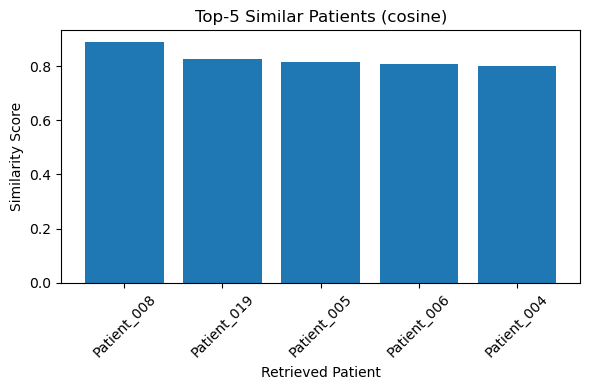

In [51]:
# ==================================================
# 4.1 Create Dummy Features
# ==================================================
np.random.seed(42)

N = 20
n_features = 8

library_features = np.random.rand(N, n_features)
query_feature = np.random.rand(1, n_features)

labels = np.random.choice(
    ["CN", "MCI", "AD", "Other"],
    size=N
)

patient_ids = [
    f"Patient_{i:03d}"
    for i in range(N)
]

print("Library shape:", library_features.shape)
print("Query shape:", query_feature.shape)


# ==================================================
# 4.2 Initialize Retriever
# ==================================================
retriever = BrainTwinRetriever(
    library_features=library_features,
    labels=labels,
    patient_ids=patient_ids
)


# ==================================================
# 4.3 Run One Method
# ==================================================
cosine_results = retriever.retrieve_top_k(
    query_feature=query_feature,
    top_k=5,
    method="cosine"
)

cosine_df = retriever.results_to_dataframe(cosine_results)

print("\nCosine Similarity Results:")
display(cosine_df)


# ==================================================
# 4.4 Test Various Methods
# ==================================================
methods = ["cosine", "euclidean", "manhattan", "correlation"]

all_results = {}

for method in methods:
    print(f"\nMethod: {method}")

    method_results = retriever.retrieve_top_k(
        query_feature=query_feature,
        top_k=5,
        method=method
    )

    method_df = retriever.results_to_dataframe(method_results)
    all_results[method] = method_df

    display(method_df)


# ==================================================
# 4.5 Test Similarity Matrix
# ==================================================
similarity_matrix = retriever.compute_similarity_matrix(
    method="cosine"
)

print("\nSimilarity matrix shape:", similarity_matrix.shape)


# ==================================================
# 4.6 Simple Visualization
# ==================================================
method_to_plot = "cosine"
df_results = all_results[method_to_plot]

print(f"\nPlotting Top-5 results for: {method_to_plot}")
print(df_results)

plt.figure(figsize=(6, 4))

plt.bar(
    df_results["patient_id"],
    df_results["similarity_score"]
)

plt.xlabel("Retrieved Patient")
plt.ylabel("Similarity Score")
plt.title(f"Top-5 Similar Patients ({method_to_plot})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
comparison_results = retriever.compare_methods(
    query_feature=query_feature,
    top_k=5
)

for method, df in comparison_results.items():
    print(f"\nMethod: {method}")
    display(df)


Method: cosine


,rank,library_index,similarity_score,method,patient_id,label
0,1,8,0.888957,cosine,Patient_008,AD
1,2,19,0.826103,cosine,Patient_019,AD
2,3,5,0.814791,cosine,Patient_005,Other
3,4,6,0.810481,cosine,Patient_006,AD
4,5,4,0.801699,cosine,Patient_004,AD



Method: euclidean


,rank,library_index,similarity_score,method,patient_id,label
0,1,8,0.572761,euclidean,Patient_008,AD
1,2,5,0.536350,euclidean,Patient_005,Other
2,3,12,0.533337,euclidean,Patient_012,Other
3,4,2,0.512422,euclidean,Patient_002,Other
4,5,19,0.509789,euclidean,Patient_019,AD



Method: manhattan


,rank,library_index,similarity_score,method,patient_id,label
0,1,8,0.389640,manhattan,Patient_008,AD
1,2,18,0.336540,manhattan,Patient_018,Other
2,3,12,0.335352,manhattan,Patient_012,Other
3,4,5,0.329007,manhattan,Patient_005,Other
4,5,2,0.328615,manhattan,Patient_002,Other



Method: correlation


,rank,library_index,similarity_score,method,patient_id,label
0,1,8,0.603477,correlation,Patient_008,AD
1,2,5,0.290057,correlation,Patient_005,Other
2,3,12,0.253573,correlation,Patient_012,Other
3,4,4,0.212654,correlation,Patient_004,AD
4,5,19,0.200387,correlation,Patient_019,AD


CSV shape: (1000, 9)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,Label
0,-2474.4185,-3195.8480,-1297.496300,-1239.90600,1534.5577,-663.31620,-1909.10740,1539.22000,0
1,-1516.4951,-1492.1394,113.780110,2106.80760,623.3778,420.47140,410.49887,-393.27866,0
2,471.0817,2738.9084,1536.662100,-170.66032,579.7401,532.69366,1756.73750,173.72168,0
3,-1516.6870,1300.0999,2.716803,-1663.63230,-1504.0299,-182.44118,278.42093,-164.23349,0
4,-3423.0203,2464.2795,1738.632300,-270.73343,1895.1306,-939.55360,2114.10180,1121.27830,0


All features shape: (1000, 8)
Query shape: (1, 8)
Library shape: (999, 8)

Method: cosine


,rank,library_index,similarity_score,method,patient_id
0,1,886,0.895884,cosine,Patient_0886
1,2,844,0.893422,cosine,Patient_0844
2,3,868,0.892451,cosine,Patient_0868
3,4,987,0.888954,cosine,Patient_0987
4,5,981,0.885416,cosine,Patient_0981
5,6,919,0.883278,cosine,Patient_0919
6,7,778,0.881709,cosine,Patient_0778
7,8,807,0.877345,cosine,Patient_0807
8,9,141,0.874920,cosine,Patient_0141
9,10,712,0.872368,cosine,Patient_0712



Method: euclidean


,rank,library_index,similarity_score,method,patient_id
0,1,141,0.000639,euclidean,Patient_0141
1,2,399,0.000562,euclidean,Patient_0399
2,3,160,0.000533,euclidean,Patient_0160
3,4,217,0.000532,euclidean,Patient_0217
4,5,489,0.000512,euclidean,Patient_0489
5,6,46,0.000482,euclidean,Patient_0046
6,7,127,0.000460,euclidean,Patient_0127
7,8,103,0.000449,euclidean,Patient_0103
8,9,254,0.000446,euclidean,Patient_0254
9,10,712,0.000435,euclidean,Patient_0712



Method: manhattan


,rank,library_index,similarity_score,method,patient_id
0,1,141,0.000264,manhattan,Patient_0141
1,2,399,0.000241,manhattan,Patient_0399
2,3,81,0.000234,manhattan,Patient_0081
3,4,217,0.000225,manhattan,Patient_0217
4,5,46,0.000219,manhattan,Patient_0046
5,6,160,0.000204,manhattan,Patient_0160
6,7,489,0.000201,manhattan,Patient_0489
7,8,127,0.000200,manhattan,Patient_0127
8,9,190,0.000198,manhattan,Patient_0190
9,10,254,0.000195,manhattan,Patient_0254



Method: correlation


,rank,library_index,similarity_score,method,patient_id
0,1,844,0.904645,correlation,Patient_0844
1,2,712,0.903129,correlation,Patient_0712
2,3,886,0.900929,correlation,Patient_0886
3,4,987,0.900804,correlation,Patient_0987
4,5,778,0.897959,correlation,Patient_0778
5,6,868,0.897056,correlation,Patient_0868
6,7,981,0.887713,correlation,Patient_0981
7,8,807,0.886394,correlation,Patient_0807
8,9,919,0.886166,correlation,Patient_0919
9,10,977,0.877888,correlation,Patient_0977


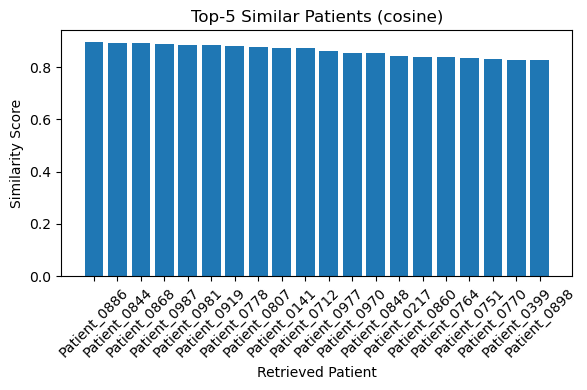

In [53]:
# ==================================================
# 5. Test Retriever Using Real Brain Signature CSV
# ==================================================

# 5.1 Load CSV file
csv_path = "brain_signatures_8d.csv"

df = pd.read_csv(csv_path)

print("CSV shape:", df.shape)
display(df.head())


# 5.2 Extract 8 PCA feature columns
feature_columns = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8"]

all_features = df[feature_columns].values

print("All features shape:", all_features.shape)


# 5.3 Choose one patient as query
query_index = 401

query_feature = all_features[query_index].reshape(1, -1)


# 5.4 Remove query patient from library
library_features = np.delete(
    all_features,
    query_index,
    axis=0
)


# 5.5 Create patient IDs for library patients
patient_ids = [
    f"Patient_{i:04d}"
    for i in range(library_features.shape[0])
]

print("Query shape:", query_feature.shape)
print("Library shape:", library_features.shape)


# 5.6 Initialize retriever
retriever = BrainTwinRetriever(
    library_features=library_features,
    patient_ids=patient_ids
)


# 5.7 Compare classical similarity methods
comparison_results = retriever.compare_methods(
    query_feature=query_feature,
    top_k=20
)

for method, result_df in comparison_results.items():
    print(f"\nMethod: {method}")
    display(result_df)


# 5.8 Plot cosine retrieval results
method_to_plot = "cosine"
df_results = comparison_results[method_to_plot]

plt.figure(figsize=(6, 4))
plt.bar(
    df_results["patient_id"],
    df_results["similarity_score"]
)

plt.xlabel("Retrieved Patient")
plt.ylabel("Similarity Score")
plt.title(f"Top-5 Similar Patients ({method_to_plot})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CSV shape: (1000, 9)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,Label
0,-2474.4185,-3195.8480,-1297.496300,-1239.90600,1534.5577,-663.31620,-1909.10740,1539.22000,0
1,-1516.4951,-1492.1394,113.780110,2106.80760,623.3778,420.47140,410.49887,-393.27866,0
2,471.0817,2738.9084,1536.662100,-170.66032,579.7401,532.69366,1756.73750,173.72168,0
3,-1516.6870,1300.0999,2.716803,-1663.63230,-1504.0299,-182.44118,278.42093,-164.23349,0
4,-3423.0203,2464.2795,1738.632300,-270.73343,1895.1306,-939.55360,2114.10180,1121.27830,0


All features shape: (1000, 8)
Query shape: (1, 8)
Query label: 0 (Non Demented)
Library shape: (999, 8)

Method: cosine
RWSS@10: 0.7643 (76.43%)
Exact Match@10: 0.3000 (30.00%)


,rank,library_index,similarity_score,method,patient_id,query_label,query_class,retrieved_label,retrieved_class,label_match,clinical_stage_score,rank_weight,weighted_contribution
0,1,154,0.901054,cosine,Patient_0155,0,Non Demented,0,Non Demented,True,1.000000,1.000000,1.000000
1,2,333,0.865667,cosine,Patient_0334,0,Non Demented,1,Very Mild Demented,False,0.666667,0.707107,0.471405
2,3,329,0.859165,cosine,Patient_0330,0,Non Demented,1,Very Mild Demented,False,0.666667,0.577350,0.384900
3,4,321,0.851412,cosine,Patient_0322,0,Non Demented,1,Very Mild Demented,False,0.666667,0.500000,0.333333
4,5,376,0.840046,cosine,Patient_0377,0,Non Demented,1,Very Mild Demented,False,0.666667,0.447214,0.298142
5,6,69,0.831550,cosine,Patient_0070,0,Non Demented,0,Non Demented,True,1.000000,0.408248,0.408248
6,7,136,0.824118,cosine,Patient_0137,0,Non Demented,0,Non Demented,True,1.000000,0.377964,0.377964
7,8,354,0.817304,cosine,Patient_0355,0,Non Demented,1,Very Mild Demented,False,0.666667,0.353553,0.235702
8,9,396,0.815049,cosine,Patient_0397,0,Non Demented,1,Very Mild Demented,False,0.666667,0.333333,0.222222
9,10,617,0.803845,cosine,Patient_0618,0,Non Demented,2,Mild Demented,False,0.333333,0.316228,0.105409



Method: euclidean
RWSS@10: 0.7677 (76.77%)
Exact Match@10: 0.3000 (30.00%)


...

,rank,library_index,similarity_score,method,patient_id,query_label,query_class,retrieved_label,retrieved_class,label_match,clinical_stage_score,rank_weight,weighted_contribution
0,1,329,0.000199,manhattan,Patient_0330,0,Non Demented,1,Very Mild Demented,False,0.666667,1.000000,0.666667
1,2,154,0.000183,manhattan,Patient_0155,0,Non Demented,0,Non Demented,True,1.000000,0.707107,0.707107
2,3,321,0.000161,manhattan,Patient_0322,0,Non Demented,1,Very Mild Demented,False,0.666667,0.577350,0.384900
3,4,136,0.000158,manhattan,Patient_0137,0,Non Demented,0,Non Demented,True,1.000000,0.500000,0.500000
4,5,617,0.000147,manhattan,Patient_0618,0,Non Demented,2,Mild Demented,False,0.333333,0.447214,0.149071
5,6,311,0.000146,manhattan,Patient_0312,0,Non Demented,1,Very Mild Demented,False,0.666667,0.408248,0.272166
6,7,306,0.000143,manhattan,Patient_0307,0,Non Demented,1,Very Mild Demented,False,0.666667,0.377964,0.251976
7,8,333,0.000136,manhattan,Patient_0334,0,Non Demented,1,Very Mild Demented,False,0.666667,0.353553,0.235702
8,9,585,0.000136,manhattan,Patient_0586,0,Non Demented,2,Mild Demented,False,0.333333,0.333333,0.111111
9,10,69,0.000134,manhattan,Patient_0070,0,Non Demented,0,Non Demented,True,1.000000,0.316228,0.316228



Method: correlation
RWSS@10: 0.8348 (83.48%)
Exact Match@10: 0.4000 (40.00%)


,rank,library_index,similarity_score,method,patient_id,query_label,query_class,retrieved_label,retrieved_class,label_match,clinical_stage_score,rank_weight,weighted_contribution
0,1,69,0.923245,correlation,Patient_0070,0,Non Demented,0,Non Demented,True,1.000000,1.000000,1.000000
1,2,154,0.913718,correlation,Patient_0155,0,Non Demented,0,Non Demented,True,1.000000,0.707107,0.707107
2,3,321,0.885823,correlation,Patient_0322,0,Non Demented,1,Very Mild Demented,False,0.666667,0.577350,0.384900
3,4,396,0.881842,correlation,Patient_0397,0,Non Demented,1,Very Mild Demented,False,0.666667,0.500000,0.333333
4,5,136,0.874399,correlation,Patient_0137,0,Non Demented,0,Non Demented,True,1.000000,0.447214,0.447214
5,6,376,0.872199,correlation,Patient_0377,0,Non Demented,1,Very Mild Demented,False,0.666667,0.408248,0.272166
6,7,209,0.847335,correlation,Patient_0210,0,Non Demented,0,Non Demented,True,1.000000,0.377964,0.377964
7,8,329,0.841874,correlation,Patient_0330,0,Non Demented,1,Very Mild Demented,False,0.666667,0.353553,0.235702
8,9,333,0.813211,correlation,Patient_0334,0,Non Demented,1,Very Mild Demented,False,0.666667,0.333333,0.222222
9,10,318,0.804846,correlation,Patient_0319,0,Non Demented,1,Very Mild Demented,False,0.666667,0.316228,0.210819



========== Method Summary ==========


,method,RWSS@10,Exact_Match@10,query_label,query_class
3,correlation,0.834780,0.4,0,Non Demented
1,euclidean,0.767718,0.3,0,Non Demented
0,cosine,0.764256,0.3,0,Non Demented
2,manhattan,0.715979,0.3,0,Non Demented


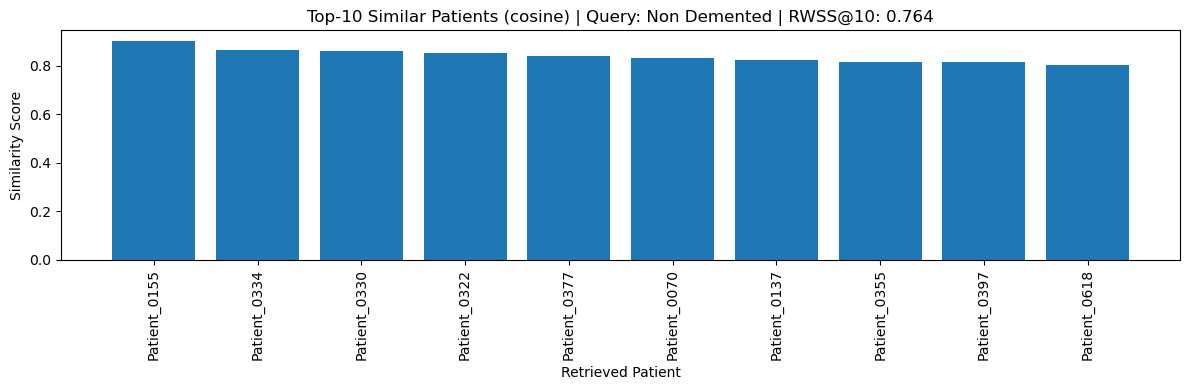

In [54]:
# ==================================================
# 5. Test Retriever Using Real Brain Signature CSV
# with Label-Aware RWSS@20 Evaluation
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 5.1 Load CSV file
csv_path = "brain_signatures_8d.csv"

df = pd.read_csv(csv_path)

print("CSV shape:", df.shape)
display(df.head())


# 5.2 Extract 8 PCA feature columns and labels
feature_columns = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8"]

all_features = df[feature_columns].values
all_labels = df["Label"].values.astype(int)

print("All features shape:", all_features.shape)


# 5.3 Choose one patient as query
query_index = 0

query_feature = all_features[query_index].reshape(1, -1)
query_label = all_labels[query_index]

class_names = {
    0: "Non Demented",
    1: "Very Mild Demented",
    2: "Mild Demented",
    3: "Moderate Demented"
}

print("Query shape:", query_feature.shape)
print(f"Query label: {query_label} ({class_names[query_label]})")


# 5.4 Remove query patient from library
library_features = np.delete(all_features, query_index, axis=0)
library_labels = np.delete(all_labels, query_index, axis=0)

library_original_indices = np.delete(np.arange(len(df)), query_index)


# 5.5 Create patient IDs for library patients
patient_ids = [
    f"Patient_{i:04d}"
    for i in library_original_indices
]

print("Library shape:", library_features.shape)


# 5.6 Initialize retriever
retriever = BrainTwinRetriever(
    library_features=library_features,
    patient_ids=patient_ids
)


# 5.7 Define RWSS functions
def clinical_stage_score(query_label, retrieved_label):
    return 1 - abs(query_label - retrieved_label) / 3


def rank_weight(rank):
    return 1 / np.sqrt(rank)


def add_labels_and_rwss(result_df, query_label, patient_ids, library_labels, k=20):
    result_df = result_df.copy()

    label_lookup = dict(zip(patient_ids, library_labels))

    result_df["rank"] = np.arange(1, len(result_df) + 1)

    result_df["query_label"] = query_label
    result_df["query_class"] = class_names[query_label]

    result_df["retrieved_label"] = result_df["patient_id"].map(label_lookup)
    result_df["retrieved_class"] = result_df["retrieved_label"].map(class_names)

    result_df["label_match"] = (
        result_df["retrieved_label"] == result_df["query_label"]
    )

    result_df["clinical_stage_score"] = result_df["retrieved_label"].apply(
        lambda lbl: clinical_stage_score(query_label, lbl)
    )

    result_df["rank_weight"] = result_df["rank"].apply(rank_weight)

    result_df["weighted_contribution"] = (
        result_df["clinical_stage_score"] * result_df["rank_weight"]
    )

    rwss_score = (
        result_df["weighted_contribution"].sum()
        / result_df["rank_weight"].sum()
    )

    exact_match_at_k = result_df["label_match"].mean()

    return result_df, rwss_score, exact_match_at_k


# 5.8 Compare classical similarity methods
K = 10

comparison_results = retriever.compare_methods(
    query_feature=query_feature,
    top_k=K
)


# 5.9 Add labels and compute RWSS for each method
scored_results = {}
summary_rows = []

for method, result_df in comparison_results.items():

    scored_df, rwss_score, exact_match = add_labels_and_rwss(
        result_df=result_df,
        query_label=query_label,
        patient_ids=patient_ids,
        library_labels=library_labels,
        k=K
    )

    scored_results[method] = scored_df

    summary_rows.append({
        "method": method,
        f"RWSS@{K}": rwss_score,
        f"Exact_Match@{K}": exact_match,
        "query_label": query_label,
        "query_class": class_names[query_label]
    })

    print(f"\nMethod: {method}")
    print(f"RWSS@{K}: {rwss_score:.4f} ({100 * rwss_score:.2f}%)")
    print(f"Exact Match@{K}: {exact_match:.4f} ({100 * exact_match:.2f}%)")
    display(scored_df)


# 5.10 Summary table
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(f"RWSS@{K}", ascending=False)

print("\n========== Method Summary ==========")
display(summary_df)


# 5.11 Plot cosine retrieval results
method_to_plot = "cosine"
df_results = scored_results[method_to_plot]

plt.figure(figsize=(12, 4))

plt.bar(
    df_results["patient_id"],
    df_results["similarity_score"]
)

plt.xlabel("Retrieved Patient")
plt.ylabel("Similarity Score")
plt.title(
    f"Top-{K} Similar Patients ({method_to_plot}) | "
    f"Query: {class_names[query_label]} | "
    f"RWSS@{K}: {summary_df.loc[summary_df['method'] == method_to_plot, f'RWSS@{K}'].values[0]:.3f}"
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [55]:
# ==================================================
# Leave-One-Out Retrieval Evaluation
# Same Logic as Single Query
# Save One CSV with Final Scores per Sample
# ==================================================

import numpy as np
import pandas as pd

# 1. Load CSV
csv_path = "brain_signatures_8d.csv"
df = pd.read_csv(csv_path)

print("CSV shape:", df.shape)
display(df.head())


# 2. Extract features and numeric labels
#feature_columns = ["PC1", "PC2", "PC3", "PC4"]
feature_columns = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8"]

all_features = df[feature_columns].values
all_labels = df["Label"].values.astype(int)

print("All features shape:", all_features.shape)
print("Unique labels:", np.unique(all_labels))


# 3. Class names
class_names = {
    0: "Non Demented",
    1: "Very Mild Demented",
    2: "Mild Demented",
    3: "Moderate Demented"
}


# 4. RWSS functions
def clinical_stage_score(query_label, retrieved_label):
    return 1 - abs(query_label - retrieved_label) / 3


def rank_weight(rank):
    return 1 / np.sqrt(rank)


def compute_rwss(result_df, query_label, patient_ids, library_labels):
    label_lookup = dict(zip(patient_ids, library_labels))

    retrieved_labels = result_df["patient_id"].map(label_lookup).values.astype(int)

    ranks = np.arange(1, len(retrieved_labels) + 1)

    clinical_scores = np.array([
        clinical_stage_score(query_label, retrieved_label)
        for retrieved_label in retrieved_labels
    ])

    weights = np.array([
        rank_weight(rank)
        for rank in ranks
    ])

    rwss = np.sum(weights * clinical_scores) / np.sum(weights)

    exact_match = np.mean(retrieved_labels == query_label)

    return rwss, exact_match


# 5. Leave-one-out loop
K = 20
n_samples = len(df)

final_rows = []

for query_index in range(n_samples):

    if query_index % 50 == 0:
        print(f"Processing query {query_index}/{n_samples}")

    query_feature = all_features[query_index].reshape(1, -1)
    query_label = int(all_labels[query_index])

    # Remove query from library
    library_features = np.delete(all_features, query_index, axis=0)
    library_labels = np.delete(all_labels, query_index, axis=0)

    library_original_indices = np.delete(np.arange(n_samples), query_index)

    patient_ids = [
        f"Patient_{i:04d}"
        for i in library_original_indices
    ]

    # Initialize retriever
    retriever = BrainTwinRetriever(
        library_features=library_features,
        patient_ids=patient_ids
    )

    # Compare all methods
    comparison_results = retriever.compare_methods(
        query_feature=query_feature,
        top_k=K
    )

    # One row per query sample
    row = {
        "query_index": query_index,
        "query_patient_id": f"Patient_{query_index:04d}",
        "query_label": query_label,
        "query_class": class_names[query_label]
    }

    # Add final score of each method to same row
    for method, result_df in comparison_results.items():

        rwss, exact_match = compute_rwss(
            result_df=result_df,
            query_label=query_label,
            patient_ids=patient_ids,
            library_labels=library_labels
        )

        row[f"{method}_RWSS@{K}"] = rwss
        row[f"{method}_ExactMatch@{K}"] = exact_match

    final_rows.append(row)


# 6. Save one CSV
final_scores_df = pd.DataFrame(final_rows)

output_csv = f"retrieval_final_scores_all_methods_RWSS_at_{K}.csv"
final_scores_df.to_csv(output_csv, index=False)

print(f"\nSaved final scores to: {output_csv}")
display(final_scores_df.head())


# 7. Overall average comparison
rwss_columns = [
    col for col in final_scores_df.columns
    if f"_RWSS@{K}" in col
]

overall_summary = pd.DataFrame({
    "method": [col.replace(f"_RWSS@{K}", "") for col in rwss_columns],
    f"Mean_RWSS@{K}": [final_scores_df[col].mean() for col in rwss_columns]
})

overall_summary = overall_summary.sort_values(
    f"Mean_RWSS@{K}",
    ascending=False
)

print("\n========== Overall Method Comparison ==========")
display(overall_summary)

CSV shape: (1000, 9)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,Label
0,-2474.4185,-3195.8480,-1297.496300,-1239.90600,1534.5577,-663.31620,-1909.10740,1539.22000,0
1,-1516.4951,-1492.1394,113.780110,2106.80760,623.3778,420.47140,410.49887,-393.27866,0
2,471.0817,2738.9084,1536.662100,-170.66032,579.7401,532.69366,1756.73750,173.72168,0
3,-1516.6870,1300.0999,2.716803,-1663.63230,-1504.0299,-182.44118,278.42093,-164.23349,0
4,-3423.0203,2464.2795,1738.632300,-270.73343,1895.1306,-939.55360,2114.10180,1121.27830,0


All features shape: (1000, 8)
Unique labels: [0 1 2 3]
Processing query 0/1000
Processing query 50/1000
Processing query 100/1000
Processing query 150/1000
Processing query 200/1000
Processing query 250/1000
Processing query 300/1000
Processing query 350/1000
Processing query 400/1000
Processing query 450/1000
Processing query 500/1000
Processing query 550/1000
Processing query 600/1000
Processing query 650/1000
Processing query 700/1000
Processing query 750/1000
Processing query 800/1000
Processing query 850/1000
Processing query 900/1000
Processing query 950/1000

Saved final scores to: retrieval_final_scores_all_methods_RWSS_at_20.csv


,query_index,query_patient_id,query_label,query_class,cosine_RWSS@20,cosine_ExactMatch@20,euclidean_RWSS@20,euclidean_ExactMatch@20,manhattan_RWSS@20,manhattan_ExactMatch@20,correlation_RWSS@20,correlation_ExactMatch@20
0,0,Patient_0000,0,Non Demented,0.750940,0.30,0.742043,0.30,0.708503,0.25,0.844792,0.50
1,1,Patient_0001,0,Non Demented,0.775004,0.40,0.740497,0.35,0.740796,0.35,0.721676,0.40
2,2,Patient_0002,0,Non Demented,0.870014,0.65,0.840170,0.55,0.862200,0.55,0.803730,0.60
3,3,Patient_0003,0,Non Demented,0.445538,0.15,0.636273,0.20,0.537134,0.15,0.669137,0.35
4,4,Patient_0004,0,Non Demented,0.931091,0.70,0.937656,0.75,0.930611,0.75,0.910822,0.75



========== Overall Method Comparison ==========


,method,Mean_RWSS@20
1,euclidean,0.813423
2,manhattan,0.810675
0,cosine,0.798817
3,correlation,0.791144


## 5. Quantum Analysis

This code implements the quantum part of the analysis, importing the parameters to apply them to a phase-encoding circuit and obtain the resulting states, comparing states via fidelity to examine the similarity of associated data points and ultimately yielding for each data point a list of the 20 closest point. This is used to calculate the ultimate sum value which is then stored in a csv file.

In [56]:
# ==========================================
# IMPORTING PACKAGES
# ==========================================

import pandas as pd
import numpy as np
import h5py
from sklearn.preprocessing import MinMaxScaler
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity

 
# ==========================================
# LOAD CSV
# ==========================================
 
#main data for similarity calculations
df = pd.read_csv("brain_signatures_8d.csv")

#additional data with labels

labels = [0]*250 + [1]*250 + [2]*250 + [3]*250

 
X = df.values


 
print("Shape:", X.shape)
 
# ==========================================
# SCALE TO [0, 2π]
# ==========================================
 
scaler = MinMaxScaler(feature_range=(0, 2*np.pi))

 
X_scaled = scaler.fit_transform(X)
 
# ==========================================
# PHASE ENCODING
# 8 features -> 8 qubits
# ==========================================
 
def phase_encode(features):
 
    qc = QuantumCircuit(8)
 
    for i in range(8):
        qc.h(i)
        qc.p(features[i], i)
 
    return Statevector.from_instruction(qc)

 
# ==========================================
# BUILD ALL QUANTUM STATES
# ==========================================
 
print("Encoding patients...")
 
quantum_states = []
 
for row in X_scaled:
    quantum_states.append(
        phase_encode(row)
    )
 
print("Done.")
 
# ==========================================
# QUERY PATIENT
# ==========================================

#initializing array for collecting weighted difference data
sums_arr = []
#iterating over number of label values
for x in range(1000):
    query_id = x
    
    query_state = quantum_states[query_id]
    
    # ==========================================
    # COMPUTE FIDELITIES
    # ==========================================
    
    similarities = []
    
    for state in quantum_states:
        #calculating fidelity between phase-encoded data points
        sim = state_fidelity(
            query_state,
            state
        )
    
        similarities.append(sim)
    
    similarities = np.array(similarities)
    
    # ==========================================
    # TOP 5 BRAIN TWINS
    # ==========================================
    
    top5 = np.argsort(
        similarities
    )[::-1][1:6]
    
    print("\nQuery Patient:", query_id)
    
    print("\nTop 5 Brain Twins:")
    
    for idx in top5:
    
        print(
            f"Patient {idx} | Fidelity = {similarities[idx]:.4f}"
        )
    
    #getting indices for sorted results
    sorted_inds = np.arange(len(similarities))[np.argsort(similarities)]
    #getting sorted labels
    sorted_labels = np.array(labels)[sorted_inds]
    #getting integer representations of 20 closest data points for comparison with main data point
    # number of categories
    L = 4
    #computing difference array for data points from main data point
    diffs = 1 - np.absolute(sorted_labels[0] - np.array(sorted_labels[1:]))/(L-1)
    #adding weighted sum (with weight of 1/sqrt(r) for 1 <= r <= 20)
    sums_arr.append(sum([1/np.sqrt(i+1)*diffs[i] for i in range(20)])/np.sum(1/np.sqrt(np.arange(1, 21))))

# ==========================================
# SAVE RESULTS
# ==========================================
results = pd.DataFrame({
        "PatientID":np.arange(1000),
        "Labels": np.array(labels),
        "QuantumSimilarity": sums_arr
    })

#saving the results as a csv file
results.to_csv("phase_encoding_results.csv")

sums_arr = np.array(sums_arr)
avgs = [np.mean(sums_arr[:250]), np.mean(sums_arr[250:500]), np.mean(sums_arr[500:750]), np.mean(sums_arr[750:])]

print("Accuracy value for no dementia:", avgs[0])
print("Accuracy value for very mild dementia:", avgs[1])
print("Accuracy value for mild dementia:", avgs[2])
print("Accuracy value for moderate dementia:", avgs[3])

Shape: (1000, 9)
Encoding patients...
Done.

Query Patient: 0

Top 5 Brain Twins:
Patient 155 | Fidelity = 0.4068
Patient 334 | Fidelity = 0.2492
Patient 322 | Fidelity = 0.2184
Patient 70 | Fidelity = 0.2167
Patient 307 | Fidelity = 0.2135

Query Patient: 1

Top 5 Brain Twins:
Patient 417 | Fidelity = 0.9278
Patient 109 | Fidelity = 0.8162
Patient 180 | Fidelity = 0.7367
Patient 63 | Fidelity = 0.6882
Patient 321 | Fidelity = 0.6736

Query Patient: 2

Top 5 Brain Twins:
Patient 14 | Fidelity = 0.9812
Patient 483 | Fidelity = 0.7968
Patient 423 | Fidelity = 0.6474
Patient 257 | Fidelity = 0.6284
Patient 464 | Fidelity = 0.6080

Query Patient: 3

Top 5 Brain Twins:
Patient 432 | Fidelity = 0.6934
Patient 409 | Fidelity = 0.6847
Patient 460 | Fidelity = 0.5864
Patient 320 | Fidelity = 0.5747
Patient 745 | Fidelity = 0.5686

Query Patient: 4

Top 5 Brain Twins:
Patient 29 | Fidelity = 0.4988
Patient 126 | Fidelity = 0.3733
Patient 16 | Fidelity = 0.3494
Patient 34 | Fidelity = 0.2947
Pati